In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from tqdm import tqdm_notebook
from scipy.spatial.distance import cityblock, cosine, euclidean, hamming, jaccard
from scipy.sparse import csr_matrix

from surprise import KNNWithMeans, KNNBaseline,  KNNBasic
from surprise import Dataset
from surprise import accuracy
from surprise import Reader
from surprise.model_selection import cross_validate
from surprise.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import fetch_openml



In [25]:
data = Dataset.load_builtin('ml-100k')

In [26]:
df = pd.DataFrame(data.raw_ratings, columns=['userId', 'movieId', 'rating', 'timestamp'])

In [27]:
df

,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596
...,...,...,...,...
99995,880,476,3.0,880175444
99996,716,204,5.0,879795543
99997,276,1090,1.0,874795795
99998,13,225,2.0,882399156


In [28]:
#  посмотрим на размер датасета  (кол-во уникальных пользователей и фильмов)

print(f"фильмы: {len(df['movieId'].unique())}.")
print(f"пользователи: {len(df['userId'].unique())}.")

фильмы: 1682.
пользователи: 943.


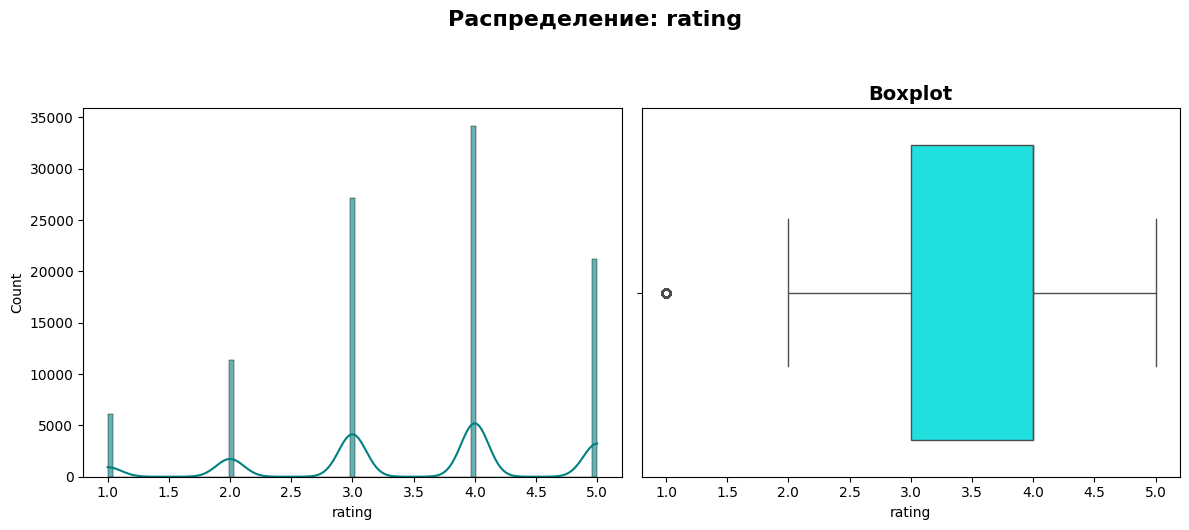

<Figure size 640x480 with 0 Axes>

In [38]:
def diagnose_distribution(df, col):
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # --- График 1: Нормальное распределение ---
  sns.histplot(df[col], kde=True, color='teal', ax=axes[0], alpha=0.6)
  mean_h = df[col].mean()
  median_h = df[col].median()
  
  # Boxplot
  sns.boxplot(x=df[col], ax=axes[1], color='cyan')
  axes[1].set_title(f'Boxplot', fontsize=14, fontweight='bold')
  
  plt.suptitle(f'Распределение: {col}', fontsize=16, fontweight='bold', y=1.05)
  plt.tight_layout()
  plt.show()

  plt.suptitle(f'Распределение: {col}', fontsize=16, fontweight='bold', y=1.05)
  plt.tight_layout()
  plt.show()

diagnose_distribution(df, 'rating')




Топ-10 активных пользователей:
        total_ratings  avg_rating  std_rating  unique_movies
userId                                                      
405               737        1.83        1.35            737
655               685        2.91        0.73            685
13                636        3.10        1.42            636
450               540        3.86        0.86            540
276               518        3.47        1.02            518
416               493        3.85        1.09            493
537               490        2.87        0.97            490
303               484        3.37        1.23            484
234               480        3.12        0.92            480
393               448        3.34        0.82            448


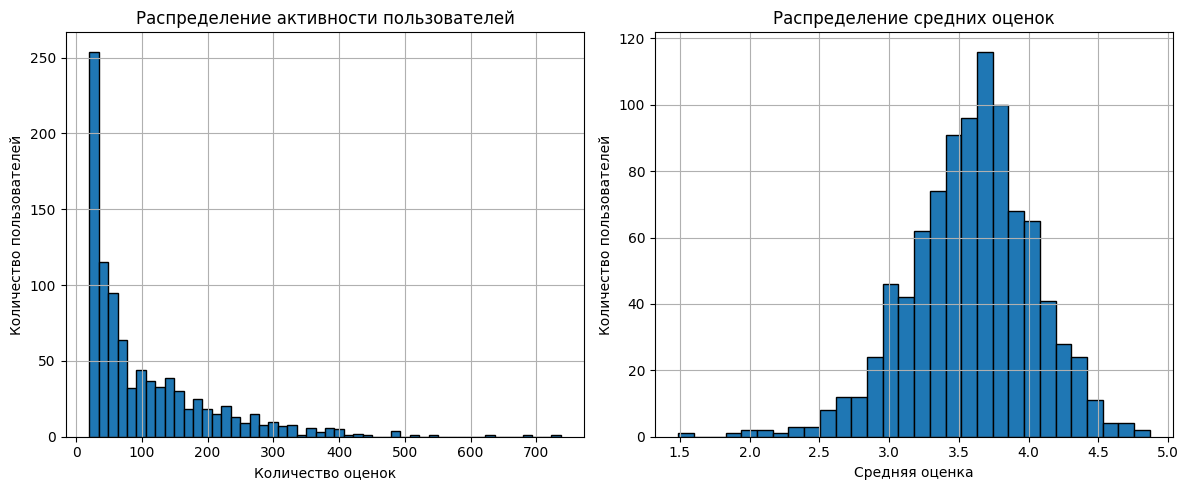

In [42]:
# Активность пользователей
user_activity = df.groupby('userId').agg({
    'rating': ['count', 'mean', 'std'],
    'movieId': 'nunique'
}).round(2)
user_activity.columns = ['total_ratings', 'avg_rating', 'std_rating', 'unique_movies']

# Топ активных пользователей
print("\nТоп-10 активных пользователей:")
print(user_activity.nlargest(10, 'total_ratings'))

# Распределение активности
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
user_activity['total_ratings'].hist(bins=50, edgecolor='black')
plt.xlabel('Количество оценок')
plt.ylabel('Количество пользователей')
plt.title('Распределение активности пользователей')

plt.subplot(1, 2, 2)
user_activity['avg_rating'].hist(bins=30, edgecolor='black')
plt.xlabel('Средняя оценка')
plt.ylabel('Количество пользователей')
plt.title('Распределение средних оценок')

plt.tight_layout()
plt.show()



Топ-10 популярных фильмов:
         total_ratings  avg_rating  std_rating  unique_users
movieId                                                     
50                 583        4.36        0.88           583
258                509        3.80        0.99           509
100                508        4.16        0.98           508
181                507        4.01        0.92           507
294                485        3.16        1.10           485
286                481        3.66        1.17           481
288                478        3.44        1.11           478
1                  452        3.88        0.93           452
300                431        3.63        1.00           431
121                429        3.44        1.12           429

Топ-10 высоко оцененных фильмов (мин. 50 оценок):
         total_ratings  avg_rating  std_rating  unique_users
movieId                                                     
408                112        4.49        0.77           112
169   

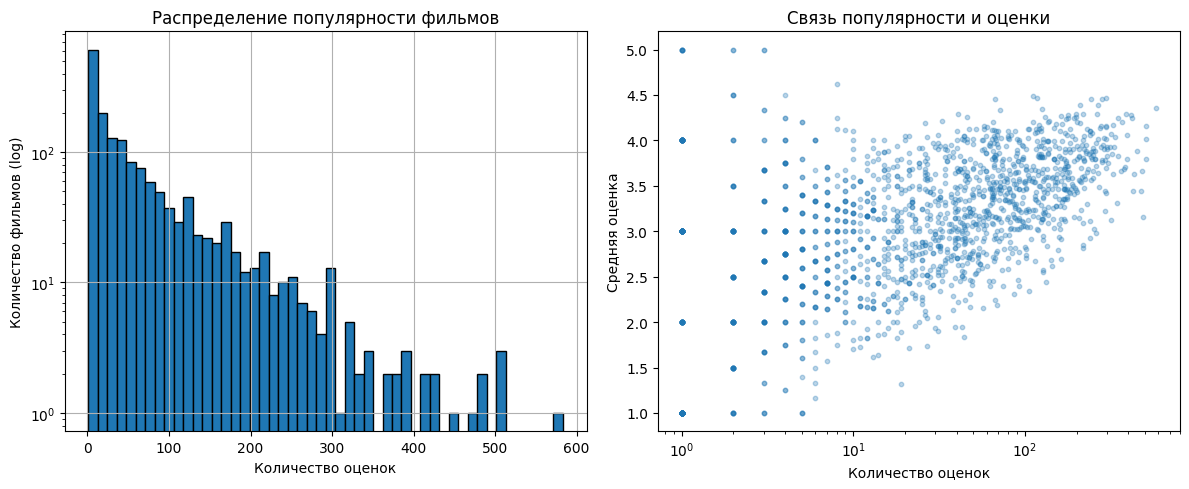

In [43]:
# Популярность фильмов
movie_popularity = df.groupby('movieId').agg({
    'rating': ['count', 'mean', 'std'],
    'userId': 'nunique'
}).round(2)
movie_popularity.columns = ['total_ratings', 'avg_rating', 'std_rating', 'unique_users']

# Топ популярных фильмов
print("\nТоп-10 популярных фильмов:")
print(movie_popularity.nlargest(10, 'total_ratings'))

# Высоко оцененные фильмы (с минимум 50 оценками)
highly_rated = movie_popularity[movie_popularity['total_ratings'] >= 50]
print("\nТоп-10 высоко оцененных фильмов (мин. 50 оценок):")
print(highly_rated.nlargest(10, 'avg_rating'))

# Визуализация популярности
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
movie_popularity['total_ratings'].hist(bins=50, edgecolor='black', log=True)
plt.xlabel('Количество оценок')
plt.ylabel('Количество фильмов (log)')
plt.title('Распределение популярности фильмов')

plt.subplot(1, 2, 2)
plt.scatter(movie_popularity['total_ratings'], 
           movie_popularity['avg_rating'], 
           alpha=0.3, s=10)
plt.xlabel('Количество оценок')
plt.ylabel('Средняя оценка')
plt.title('Связь популярности и оценки')
plt.xscale('log')

plt.tight_layout()
plt.show()


Размер матрицы: 943 x 1682
Количество оценок: 100000
Разреженность матрицы: 93.6953%


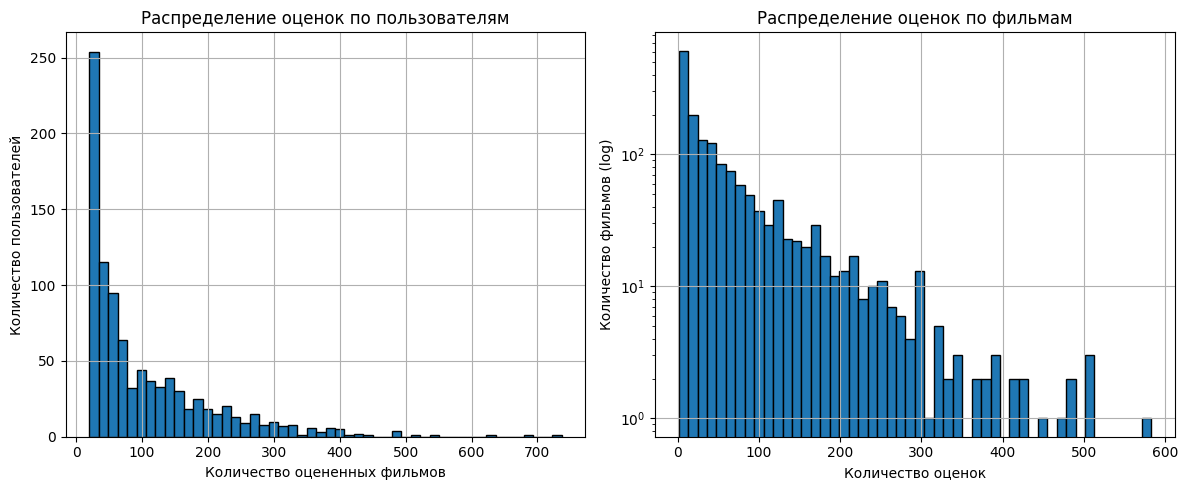


Размер sparse матрицы в памяти: 0.76 MB
Размер dense матрицы в памяти: 12.10 MB


In [46]:
# Создание матрицы user-item
user_item_matrix = df.pivot_table(
    index='userId', 
    columns='movieId', 
    values='rating',
    fill_value=0
)

# Размер матрицы
n_users = user_item_matrix.shape[0]
n_movies = user_item_matrix.shape[1]
n_ratings = len(df)

print(f"\nРазмер матрицы: {n_users} x {n_movies}")
print(f"Количество оценок: {n_ratings}")

# Разреженность матрицы
sparsity = 1 - (n_ratings / (n_users * n_movies))
print(f"Разреженность матрицы: {sparsity:.4%}")

# Плотность распределения
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Распределение оценок по пользователям
user_ratings_count = user_item_matrix.astype(bool).sum(axis=1)
user_ratings_count.hist(bins=50, edgecolor='black')
plt.xlabel('Количество оцененных фильмов')
plt.ylabel('Количество пользователей')
plt.title('Распределение оценок по пользователям')

plt.subplot(1, 2, 2)
# Распределение оценок по фильмам
movie_ratings_count = user_item_matrix.astype(bool).sum(axis=0)
movie_ratings_count.hist(bins=50, edgecolor='black', log=True)
plt.xlabel('Количество оценок')
plt.ylabel('Количество фильмов (log)')
plt.title('Распределение оценок по фильмам')

plt.tight_layout()
plt.show()

# Использование sparse матрицы для эффективности
sparse_matrix = csr_matrix(user_item_matrix.values)
print(f"\nРазмер sparse матрицы в памяти: {sparse_matrix.data.nbytes / 1024 / 1024:.2f} MB")
print(f"Размер dense матрицы в памяти: {user_item_matrix.values.nbytes / 1024 / 1024:.2f} MB")

In [30]:
# датасет для Surprise

dataset = pd.DataFrame( {
    'u_id'   : df['userId'],
    'i_id'   : df['movieId'],
    'rating' : df['rating']
})

dataset.head()

,u_id,i_id,rating
0,196,242,3.0
1,186,302,3.0
2,22,377,1.0
3,244,51,2.0
4,166,346,1.0


In [31]:
#  Max и Min значения по рейтингу
print( dataset['rating'].min(), dataset['rating'].max() )

1.0 5.0


In [32]:
# данные для создания модели

reader = Reader(rating_scale=(dataset['rating'].min(), dataset['rating'].max()))
data = Dataset.load_from_df(dataset, reader)

In [47]:
# создадим таблицу для записи результатов
# Метрики качества: | модель | подход | RMSE |
total = pd.DataFrame( columns=['модель','подход', 'RMSE', 'MAE'])
total

,модель,подход,RMSE,MAE


In [48]:
# модель KNNBaseline.
# user_based подход

algo = KNNBaseline(k=40, sim_options={'name': 'pearson_baseline', 'user_based': True})
res = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

print(f"RMSE: {np.mean(res['test_rmse']):.4f} ± {np.std(res['test_rmse']):.4f}")
print(f"MAE: {np.mean(res['test_mae']):.4f} ± {np.std(res['test_mae']):.4f}")

# Добавление в DataFrame
total = pd.concat([total, pd.DataFrame([{
    'модель': 'KNNBaseline',
    'подход': "user_based", 
    'RMSE': np.mean(res['test_rmse']),
    'MAE': np.mean(res['test_mae'])  # Добавляем MAE
}])], ignore_index=True)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBaseline on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9200  0.9263  0.9223  0.9242  0.9187  0.9223  0.0027  
MAE (testset)     0.7201  0.7236  0.7200  0.7239  0.7203  0.7216  0.0018  
Fit time          0.95    0.84    0.84    0.96    0.91    0.90    0.05    
Test time         1.54    1.56    1.60    1.47    1.7

In [49]:
# item based подход

algo = KNNBaseline(k=40, sim_options={'name': 'pearson_baseline', 'user_based': False})
res = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5)

print(f"RMSE: {np.mean(res['test_rmse']):.4f} ± {np.std(res['test_rmse']):.4f}")
print(f"MAE: {np.mean(res['test_mae']):.4f} ± {np.std(res['test_mae']):.4f}")

total = pd.concat([total, pd.DataFrame([{
    'модель': 'KNNBaseline',
    'подход': "item_based", 
    'RMSE': np.mean(res['test_rmse']),
    'MAE': np.mean(res['test_mae'])  # Добавляем MAE
}])], ignore_index=True)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
RMSE: 0.9166 ± 0.0029
MAE: 0.7188 ± 0.0023


In [50]:
total.sort_values(by = 'RMSE', ascending = True, inplace=True)

total

,модель,подход,RMSE,MAE
1,KNNBaseline,item_based,0.916575,0.718792
0,KNNBaseline,user_based,0.922281,0.721589


Лучшая модель KNNBaseline item based подход, RMSE = 0,916

In [112]:
# Отдельная модель для рекомендаций
algo = KNNBaseline(k=40, sim_options={'name': 'pearson_baseline', 'user_based': False})
trainset = data.build_full_trainset()
algo.fit(trainset)

def get_top10(user_id):
    rated = dataset[dataset['u_id'] == user_id]['i_id'].unique()
    unrated = [m for m in dataset['i_id'].unique() if m not in rated]
    preds = [(m, algo.predict(user_id, m).est) for m in unrated]
    preds.sort(key=lambda x: x[1], reverse=True)
    return preds[:10]

print("Пользователь 1:", get_top10('1')[:3])
print("Пользователь 100:", get_top10('112')[:3])
print("Пользователь 500:", get_top10('500')[:3])

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Пользователь 1: [('408', np.float64(4.893521845637711)), ('1656', np.float64(4.8327965717504675)), ('483', np.float64(4.790858850513005))]
Пользователь 100: [('318', np.float64(4.924292743853406)), ('498', np.float64(4.869444153162706)), ('519', np.float64(4.850700528186648))]
Пользователь 500: [('603', np.float64(4.546736724991466)), ('474', np.float64(4.450374539695506)), ('169', np.float64(4.437047029195162))]


Для разных пользователей рекомендуются разные фильмы